# E10 - a crop-loss model: feature selection, fitting, and what it is actually worth

**The first supervised agronomic outcome this project has had.** The product's own `field_outcomes`
table is still empty (`data/store.py:label_join` - *"It returns nothing today, and that is the
point"*), so every model here until now trained on a **proxy** target derived from NDVI. GHS-Panel
Wave 5 carries a real one.

**Target.** `sa3iq6` - "was the area harvested of [CROP] on [PLOT] less than the area planted?" -
at plot x crop grain, with the censoring category removed. Built by
`experiments/E10-croploss/build_dataset.py`, selected and fitted by `select_and_fit.py`.

**Sources.** Nigeria GHS-Panel Wave 5, [catalog/6410](https://microdata.worldbank.org/index.php/catalog/6410)
- **[verified]**. Grouped cross-validation as spatial blocking follows the same reasoning as
leave-one-cluster-out in [docs/CONCEPTS.md](../docs/CONCEPTS.md). Permutation importance:
Breiman (2001) / Fisher et al. (2019) - **[UNVERIFIED]**.

## 1. Setup

In [1]:
import json, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rep = json.load(open("../experiments/E10-croploss/model_report.json"))
scr = json.load(open("../experiments/E10-croploss/leakage_screen.json"))
d = pd.read_parquet("../experiments/E10-croploss/dataset.parquet")
print(f"rows {rep['n_rows']}   loss rate {rep['loss_rate']:.1%}   EAs {rep['n_ea']}   "
      f"households {scr['n_households']}")
d.head(3)

rows 9376   loss rate 20.8%   EAs 359   households 3142


,hhid,plotid,cropcode,ea,state,zone,crop_loss,SR_hect,gps_area_m2,rent_paid,...,plant_month,has_extension_access,asset_score,market_access_score,crop_diversity,irrigated,used_fertilizer,animal_traction,n_crops_on_plot,crop
0,10005,2,1020. CASSAVA,670,1. Abia,4. South East,0,0.0285,188.38,NaN,...,4.0,False,0.058824,0.972,1,0.0,1.0,0.0,2,CASSAVA
1,10005,2,1080. MAIZE,670,1. Abia,4. South East,1,0.0285,188.38,NaN,...,4.0,False,0.058824,0.972,1,0.0,1.0,0.0,2,MAIZE
2,10009,2,1020. CASSAVA,0,1. Abia,4. South East,0,0.0100,676.87,5000.0,...,4.0,False,0.058824,NaN,1,1.0,0.0,0.0,3,CASSAVA


## 2. The label, and the censoring that would have poisoned it

The largest single "cause" of *area harvested < area planted* is **Have Not Completed Harvest** -
695 of 2,647 raw positives, 26.3%. That is interview timing, not crop loss.

Those rows are **dropped, not relabelled `0`**: we do not know whether the remaining area would
eventually have been harvested. Calling them "no loss" would be as wrong as calling them loss.

In [2]:
R = "../data/lsms/NGA_2023_GHSP-W5_v01_M_Stata/"
h = pd.read_stata(glob.glob(R+"**/secta3i_harvestw5.dta", recursive=True)[0], convert_categoricals=True)
raw = h.sa3iq6.astype(str).str.startswith("1")
cen = h.sa3iq7_1.astype(str).str.contains("Not Completed", case=False, na=False)
print(f"raw positives             : {raw.sum()}")
print(f"  censoring (dropped)     : {(raw & cen).sum()}  ({(raw & cen).sum()/raw.sum():.1%})")
print(f"  true crop loss (label=1) : {(raw & ~cen).sum()}")
print(f"\nfinal dataset: {rep['n_rows']} rows, positive rate {rep['loss_rate']:.1%}")

raw positives             : 2647
  censoring (dropped)     : 695  (26.3%)
  true crop loss (label=1) : 1952

final dataset: 9376 rows, positive rate 20.8%


## 3. The leakage screen - applied by RULE, before any statistic

No importance score can rescue a feature computed from the label. Four categories are excluded
before the data is even assembled.

In [3]:
pd.DataFrame([{"category": k, "excluded": ", ".join(v)} for k, v in scr["banned_by_rule"].items()])

,category,excluded
0,harvest-derived (circular),"sa3iq9a, sa3iq9b, sa3iq9_conv, sa3iq10, sa3iq1..."
1,same-interview restatement,"s10q1a, s10q2a, s10q3a, s10q4a, s10q5a, s10q6a..."
2,attributed cause of the label,"sa3iq7_1, sa3iq7_2, sa3iq12, sa3iq13_1, sa3iq13_2"
3,protected,"head_gender, household_max_education"


The second row is the one that is easy to get wrong. The `sect10` shock questions - *"did your
household face difficult times due to drought?"* - correlate strongly with the outcome
(notebook 08 section 10 shows a **3.20x lift**). They are asked of the same household, in the same
interview, about the same season. That makes them a **restatement of the outcome**, not a predictor
of it. They validate the label in the EDA and are excluded from every model here.

Including them would have produced a much better-looking model that predicted nothing.

## 4. Selection in three stages, cheapest first

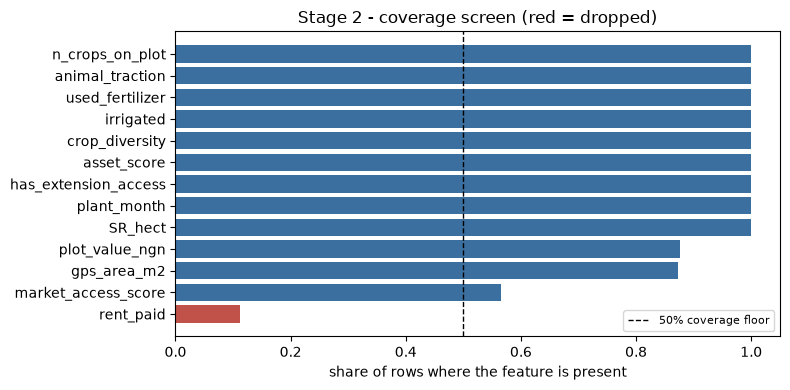

In [4]:
cov = pd.Series(rep["coverage_screen"]).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cov.index, cov.values, color=["#c0524a" if v < 0.5 else "#3b6fa0" for v in cov.values])
ax.axvline(0.5, color="k", ls="--", lw=1, label="50% coverage floor")
ax.set_xlabel("share of rows where the feature is present"); ax.legend(fontsize=8)
ax.set_title("Stage 2 - coverage screen (red = dropped)")
fig.tight_layout(); plt.show()

**Why a coverage floor rather than imputation:** below half the rows, an imputed value means the
model learns the imputation. Missingness is also informative here - a plot with no fertiliser record
usually had no fertiliser - so imputing to a median actively destroys signal.

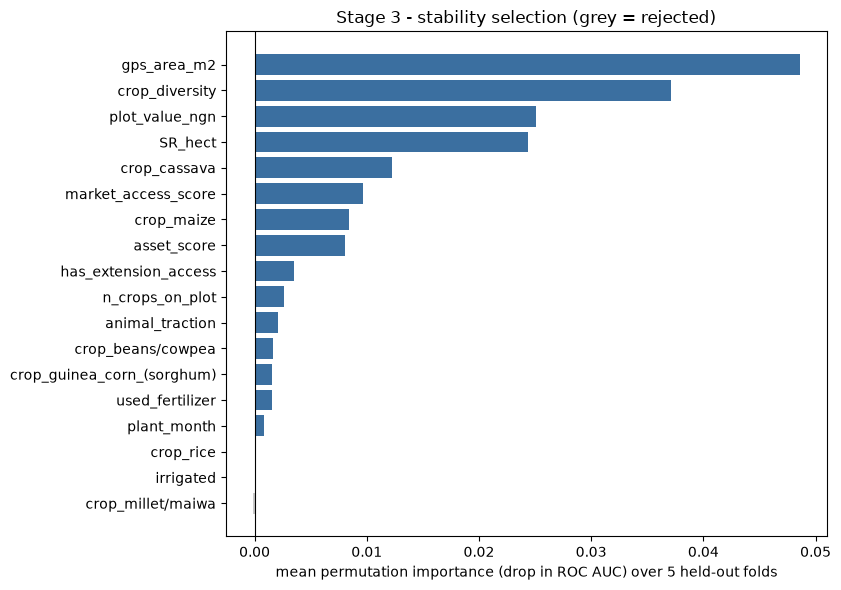

,mean_importance,folds_positive
gps_area_m2,0.04857,5.0
crop_diversity,0.03712,5.0
plot_value_ngn,0.02504,5.0
SR_hect,0.02435,5.0
crop_cassava,0.01221,5.0
market_access_score,0.00970,4.0
crop_maize,0.00838,5.0
asset_score,0.00806,5.0
has_extension_access,0.00355,4.0
n_crops_on_plot,0.00261,4.0


In [5]:
stab = pd.DataFrame(rep["stability"]).T.sort_values("mean_importance", ascending=False)
sel = set(rep["selected"])
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(stab.index[::-1], stab.mean_importance[::-1],
        color=["#3b6fa0" if f in sel else "#c9c9c9" for f in stab.index[::-1]])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("mean permutation importance (drop in ROC AUC) over 5 held-out folds")
ax.set_title("Stage 3 - stability selection (grey = rejected)")
fig.tight_layout(); plt.show()
stab.round(5)

**Stability, not a single ranking.** Permutation importance is recomputed on every held-out fold
and a feature is kept only if it beats zero on a **majority** of folds. At ~9,400 rows a one-shot
ranking on one split reliably promotes noise into the model.

`irrigated` was rejected - positive in 1 fold of 5, which is what you would expect of a variable
true for 2.3% of households (notebook 08 section 6).

## 5. Fit - and the baselines that stop the headline being overstated

An AUC means nothing on its own. Two trivial models are fitted alongside: one that knows **only the
crop**, one that knows **only the plot area** (notebook 08 section 12 showed loss rate rises with
area). Whatever the full model adds over those is what it has actually learned.

All validation is **GroupKFold by enumeration area**. Households in one EA share weather, community
infrastructure and planting calendars; a random row split puts neighbours on both sides and inflates
every score.

In [6]:
res = pd.DataFrame(rep["results"]).T
res["n_features"] = res.features.map(len)
tbl = res[["n_features","auc","auc_sd","pr_auc","brier"]].astype(float).round(3)
base = pd.DataFrame({"n_features":[0],"auc":[0.5],"auc_sd":[0.0],
                     "pr_auc":[round(rep["loss_rate"],3)],"brier":[np.nan]},
                    index=["prevalence baseline"])
pd.concat([base, tbl])

,n_features,auc,auc_sd,pr_auc,brier
prevalence baseline,0.0,0.500,0.000,0.208,NaN
crop identity only,7.0,0.655,0.021,0.309,0.157
plot area only,1.0,0.646,0.025,0.308,0.158
all candidates,18.0,0.728,0.023,0.420,0.147
SELECTED,15.0,0.727,0.024,0.418,0.147
"SELECTED, logistic",15.0,0.694,0.011,0.363,0.153


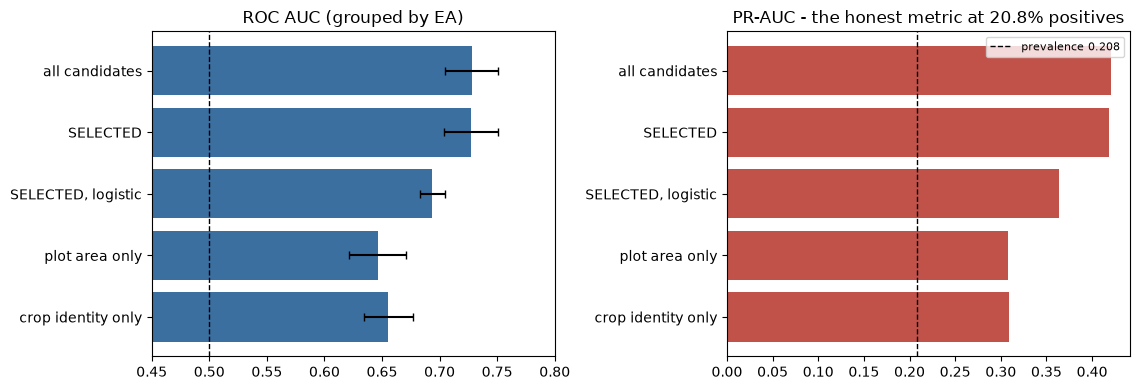

In [7]:
order = ["crop identity only","plot area only","SELECTED, logistic","SELECTED","all candidates"]
o = res.loc[[x for x in order if x in res.index]]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].barh(o.index, o.auc.astype(float), color="#3b6fa0",
             xerr=o.auc_sd.astype(float), error_kw=dict(ecolor="k", capsize=3))
axes[0].axvline(0.5, color="k", ls="--", lw=1); axes[0].set_xlim(0.45, 0.80)
axes[0].set_title("ROC AUC (grouped by EA)")
axes[1].barh(o.index, o.pr_auc.astype(float), color="#c0524a")
axes[1].axvline(rep["loss_rate"], color="k", ls="--", lw=1,
                label=f"prevalence {rep['loss_rate']:.3f}")
axes[1].legend(fontsize=8); axes[1].set_title("PR-AUC - the honest metric at 20.8% positives")
fig.tight_layout(); plt.show()

**Reading it honestly.** Crop identity alone reaches AUC 0.655 and plot area alone 0.646, so the
full model's 0.727 is a real but **modest** gain over the best trivial explanation - not a gain over
nothing. PR-AUC doubling from the 0.208 prevalence baseline to 0.418 is the fairer headline at this
positive rate.

Gradient boosting beats logistic by only 0.033 AUC, so **most of the signal is linear**. Worth
knowing before anyone reaches for a heavier model.

Selection kept 15 of 18 features and cost 0.001 AUC.

## 6. Calibration - which matters more than AUC for this product

The risk model composes probabilities through `noisy_or`. A well-ranked but badly-scaled probability
would corrupt the composition, so calibration is the property to check.

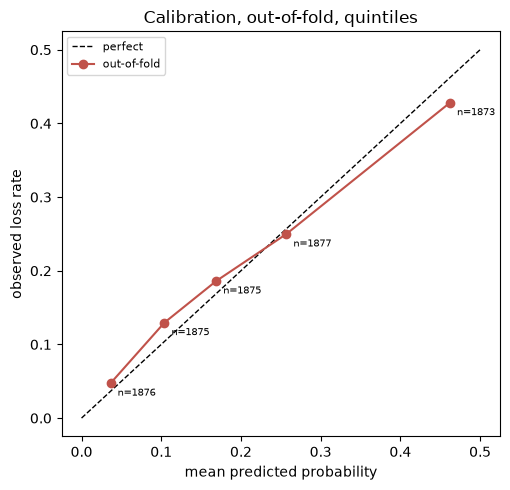

,predicted,observed,n
0,0.0365,0.0474,1876
1,0.1040,0.1296,1875
2,0.1690,0.1861,1875
3,0.2570,0.2499,1877
4,0.4623,0.4282,1873


In [8]:
cal = pd.DataFrame(rep["calibration"])
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 0.5], [0, 0.5], "k--", lw=1, label="perfect")
ax.plot(cal.predicted, cal.observed, "o-", color="#c0524a", label="out-of-fold")
for r in cal.itertuples():
    ax.annotate(f"n={r.n}", (r.predicted, r.observed), fontsize=7,
                xytext=(5, -9), textcoords="offset points")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed loss rate")
ax.set_title("Calibration, out-of-fold, quintiles"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
cal

Monotone across all five bins and close to the diagonal - mildly **under**-confident in the middle
and slightly **over**-confident in the top bin (predicted 0.462, observed 0.428). Usable as a
probability, not only as a ranking.

## 7. What this is, and what it is not

**It is** the first model in this repository fitted to a *real* agronomic outcome rather than an
NDVI-derived proxy, with the leakage screen applied by rule, spatial blocking by EA,
stability-based selection, and calibration reported.

**It is not** a drop-in replacement for anything in `domain.risk`:

* **Different population.** GHS-Panel is a national survey sample, not this product's registered
  farmers. The falsification test is in
  [experiments/E07-lsms/FINDINGS.md](../experiments/E07-lsms/FINDINGS.md).
* **Different features.** It uses plot and household attributes the serving path does not have -
  `plot_value_ngn`, `gps_area_m2`, `animal_traction`. It cannot be served as-is.
* **No weather or satellite.** These households have **no coordinates** - this release ships none
  (notebook 07, joining spec section 4b) - so nothing agro-climatic could enter. A model of crop
  loss with no weather in it is a floor, not a ceiling.
* **One season.** No temporal validation is possible from a single wave, so nothing here says the
  relationship is stable across years.

**What it is genuinely useful for:** it establishes that plot and household attributes alone carry
**AUC 0.727 / PR-AUC 0.418** against a real loss outcome. Any future model that adds weather and
satellite has that as the number to beat - and if it does not beat it, the agro-climatic features
are not earning their place.